C:\Users\admin\AppData\Local\Temp\ipykernel_5204\310223749.py:9: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  temperature_2m = df.pivot("Latitude", "Longitude", "Temperature").values
c:\Users\admin\miniconda3\envs\tf\lib\site-packages\geopandas\tools\clip.py:67: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


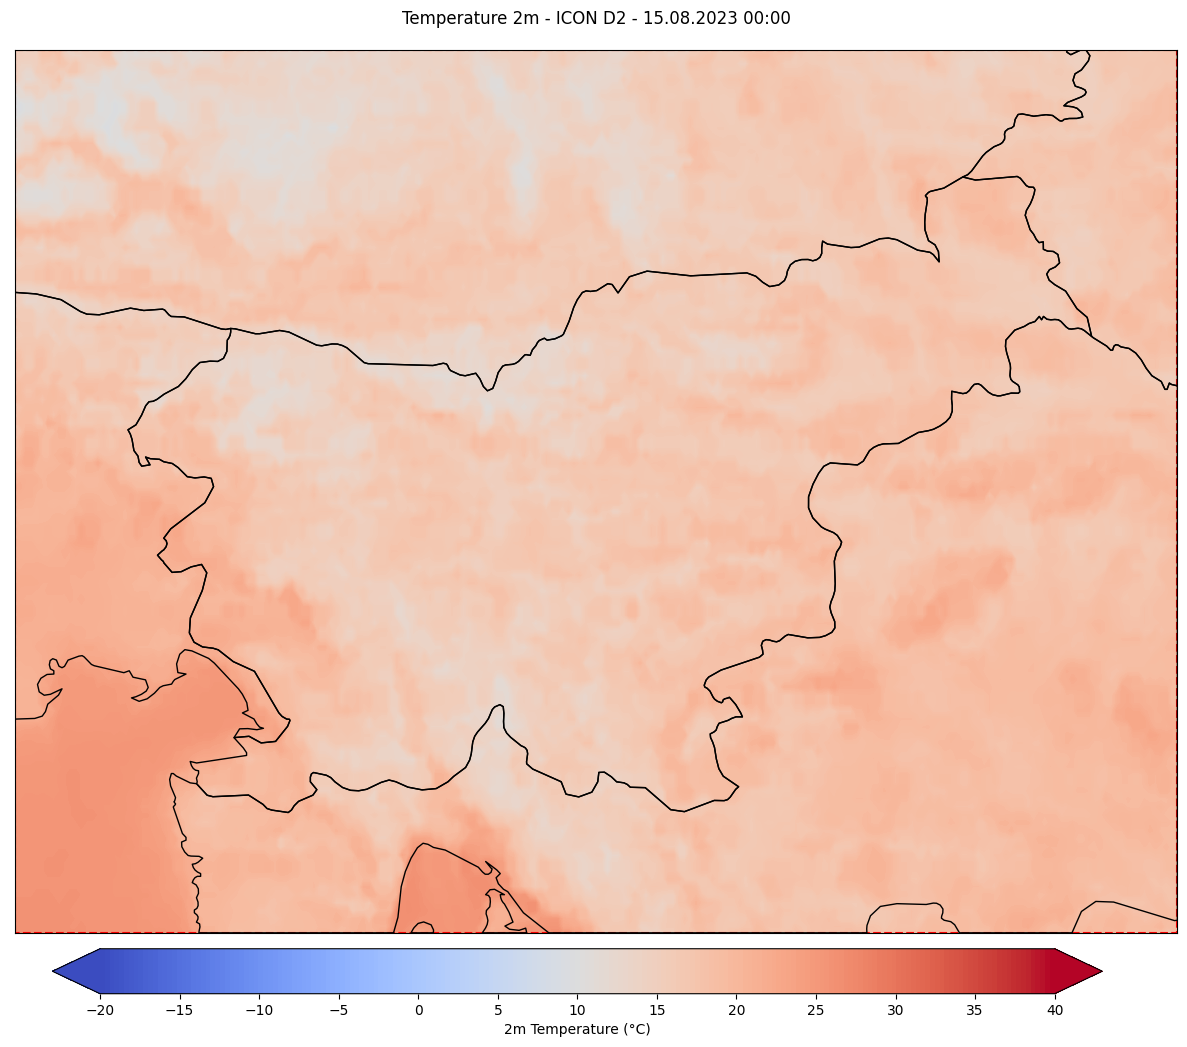

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import numpy as np

# Read the temperature data
df = pd.read_csv('../data/test/temperature/temperature_data_2_2_2_2.csv')
temperature_2m = df.pivot("Latitude", "Longitude", "Temperature").values
lat_values = df['Latitude'].unique()
lon_values = df['Longitude'].unique()

# Load the world map with medium resolution
world = gpd.read_file('../data/shapes/shape/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')

# Define the neighboring countries
countries = ['Slovenia', 'Austria', 'Italy', 'Hungary', 'Croatia']

# Filter the neighboring countries
region = world[world['NAME'].isin(countries)]

# Create bounding box for the region
latitude_center, longitude_center = 46.1512, 14.9955
lat_min = latitude_center - 1
lat_max = latitude_center + 1
lon_min = longitude_center - 2
lon_max = longitude_center + 1.80

bbox_polygon = Polygon([(lon_min, lat_min), (lon_min, lat_max), (lon_max, lat_max), (lon_max, lat_min)])

# Adjust the bounding box of the region to match the defined bounding box
region_clipped = gpd.clip(region, bbox_polygon)

# Plot the bounding areas with detailed geometries
fig, ax = plt.subplots(figsize=(15, 15))
region_clipped.plot(ax=ax, color='lightgrey', edgecolor='black')
gpd.GeoSeries(bbox_polygon).boundary.plot(ax=ax, color='red', linestyle='--')

# Clip temperature values within the desired range and set contour levels
temperature_2m_clipped = np.clip(temperature_2m, -20, 40)
contour_levels = np.linspace(-20, 40, 200)

# Plot the 2m temperature within bounding box
contour_plot = ax.contourf(lon_values, lat_values, temperature_2m_clipped, levels=contour_levels, cmap='coolwarm', extend='both')

# Add borders between countries
region_clipped.boundary.plot(ax=ax, linewidth=1, color='black')

plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)

# Remove x and y axis
plt.xticks([])
plt.yticks([])

# Set the title on top of the plot
plt.title("Temperature 2m - ICON D2 - 15.08.2023 00:00", y=1.02)

# Create axes for the colorbar to make it the same width as the plot, and place at the very bottom
cax = fig.add_axes([0.15, 0.16, 0.7, 0.03])
ticks = np.arange(-20, 41, step=5) # Fixed tick levels
cbar = plt.colorbar(contour_plot, cax=cax, orientation='horizontal', ticks=ticks, label="2m Temperature (°C)")

plt.show()  